In [1]:
import sys
import gams
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import gdxpds
from pandas.api.types import CategoricalDtype

# Get the absolute path of the Pybalmorel folder
pybalmorel_path = os.path.abspath("/Users/maxfavrot/Balmorel/pybalmorel_MaxF")

# Set the correct path for GAMS
gams_path = "/Library/Frameworks/GAMS.framework/Versions/48/Resources"

# Add Pybalmorel to Python's module search path
if pybalmorel_path not in sys.path:
    sys.path.insert(0, pybalmorel_path)

# Now, you can import your modules
from src.pybalmorel import MainResults
from src.pybalmorel.utils import symbol_to_df

# Set environment variables
os.environ["PATH"] = gams_path + ":" + os.environ.get("PATH", "")
os.environ["DYLD_LIBRARY_PATH"] = gams_path + ":" + os.environ.get("DYLD_LIBRARY_PATH", "")



Especially on Linux, gdxpds should be imported before pandas to avoid a library conflict. Also make sure your GAMS directory is listed in LD_LIBRARY_PATH.
Unable to load gdxcc with default GAMS directory 'None'. You may need to explicitly call gdxpds.load_gdxcc(gams_dir) before importing pandas to avoid a library conflict.


## Plotter class

In [2]:
class ThesisPlotter:
    def __init__(self,
                 style='whitegrid',
                 palette='Set2',
                 font_scale=1.2,
                 context='notebook',
                 figsize=(10, 6),
                 dpi=100):
        sns.set_theme(style=style, palette=palette, context=context)
        sns.set_context(context, font_scale=font_scale)
        self.figsize = figsize
        self.dpi = dpi
        self.palette = sns.color_palette(palette)

    def barplot(self, df, category_col, value_col, scenario_col,
                title="", unit="", ylabel=None, xlabel=None, legend_title="Scenario",
                save=False):
        """
        Create a barplot comparing scenarios across categories.

        Parameters:
        - df: DataFrame with the input data
        - category_col: column to be used on the x-axis (e.g., "Technology")
        - value_col: column with the values (e.g., "Value")
        - scenario_col: column with different scenarios (used as hue)
        - title: plot title
        - unit: unit displayed on y-axis
        - ylabel: custom y-axis label
        - xlabel: custom x-axis label
        - legend_title: title for the legend
        - save: if true, saves the figure
        """
        plt.figure(figsize=self.figsize, dpi=self.dpi)
        ax = sns.barplot(data=df,
                         x=category_col,
                         y=value_col,
                         hue=scenario_col,
                         palette=self.palette,
                         errorbar=None)

        ax.set_title(title, fontsize=14, weight='bold')
        ax.set_ylabel(ylabel if ylabel else f"{value_col} [{unit}]" if unit else value_col)
        ax.set_xlabel(xlabel if xlabel else category_col)
        ax.legend(title=legend_title)
        plt.xticks()
        plt.tight_layout()

        if save:
            plt.savefig("test.png", dpi=100)
        plt.show()

plotter = ThesisPlotter()


In [3]:
### 1.1.2 Loading several scenarios
res_1 = MainResults(files=['MainResults_B_B.gdx', 'MainResults_B_HDISC.gdx', 'MainResults_B_excel.gdx'], paths='../master_thesis/main_results/MainResults', scenario_names=['Base Case', 'SC2', 'SC3'])

/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_B_B.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_B_HDISC.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_B_excel.gdx


In [4]:
### 1.1.2 Loading several scenarios
res_2 = MainResults(files=['MainResults_B_B.gdx', 'MainResults_B_LDISC.gdx', 'MainResults_B_HDISC.gdx'], paths='../master_thesis/main_results/MainResults', scenario_names=['Base Case', 'Low DR', 'High DR'])


/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_B_B.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_B_LDISC.gdx
/Users/maxfavrot/Balmorel/Balmorel_MaxF/master_thesis/main_results/MainResults/MainResults_B_HDISC.gdx


In [ ]:
### 1.1.3 Plotting bar charts with an interactive gui
res_2.interactive_bar_chart()

Result type: balmorel


GridBox(children=(Dropdown(description='Table:', layout=Layout(width='80%'), options=('F_CONS_YCRA', 'F_CONS_Y…

Output()

Stack(children=(GridBox(children=(SelectMultiple(description='Scenario', index=(0,), layout=Layout(height='99%…

Output()

Output()

HBox()

Output()

Output()

Output()

In [44]:
### 1.1.5 Plotting map of transmission capacity 
fig, ax = res_1.plot_map(scenario='Base Case', year=2030, commodity='Hydrogen', lines='FlowYear', generation='Production')

Found MainResults in ../master_thesis/main_results/MainResults/MainResults_B_B.gdx


/Users/maxfavrot/Balmorel/pybalmorel_MaxF/src/pybalmorel/plotting/maps_balmorel.py:807: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_line_new = pd.concat([df_line_new, df_line.loc[[k]]], ignore_index=True)


Error in callback <function flush_figures at 0x133ad8540> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Found MainResults in ../master_thesis/main_results/MainResults/MainResults_B_B.gdx


/Users/maxfavrot/Balmorel/pybalmorel_MaxF/src/pybalmorel/plotting/maps_balmorel.py:807: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_line_new = pd.concat([df_line_new, df_line.loc[[k]]], ignore_index=True)


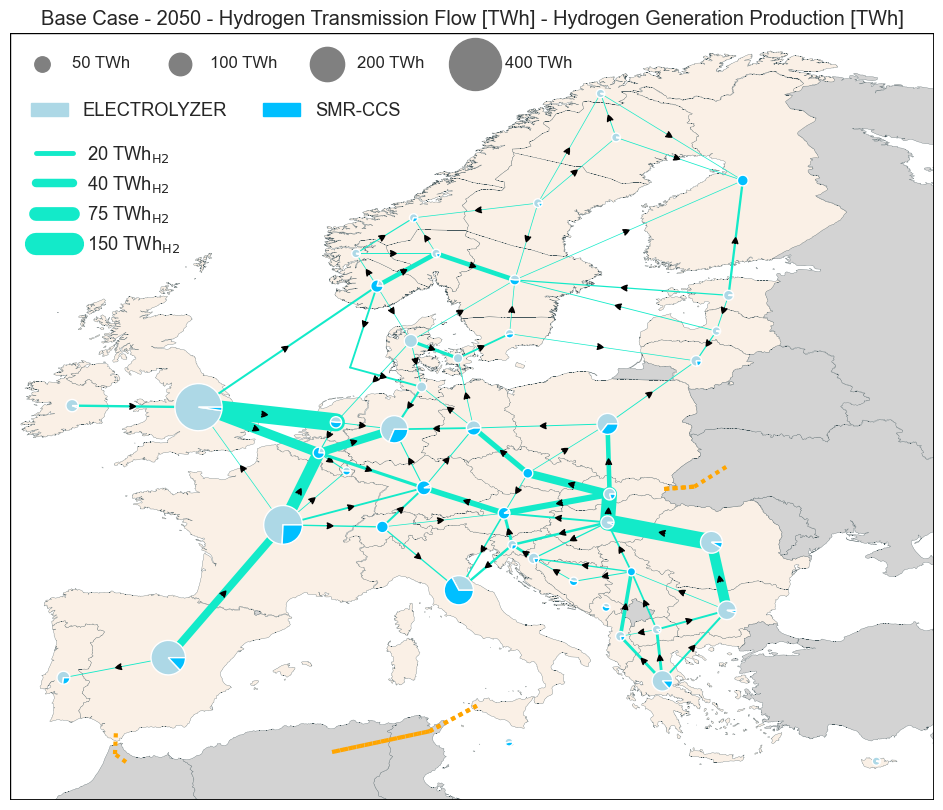

In [43]:
### 1.1.5 Plotting map of transmission capacity 
fig, ax = res_2.plot_map(scenario='Base Case', year=2050, commodity='Hydrogen', lines='FlowYear', generation='Production'
                         ,line_width_max= 13, pie_radius_max = 1.2
                         , line_legend_cluster_values=[20, 40, 75, 150], pie_legend_cluster_values=[50, 100, 200, 400])

In [9]:
help(res_2.plot_map)

Help on method plot_map in module src.pybalmorel.classes:

plot_map(scenario: str, year: int, commodity: str = None, lines: str = None, generation: str = None, background: str = None, save_fig: bool = False, path_to_geofile: str = None, geo_file_region_column: str = 'id', **kwargs) -> Tuple[matplotlib.figure.Figure, matplotlib.axes._axes.Axes] method of src.pybalmorel.classes.MainResults instance
    Plots the transmission capacities or flow in a scenario, of a certain commodity and the generation capacities or production of the regions.
    
    Args:
        path_to_result (str): Path to the .gdx file
        scenario (str): The scenario name       
        year (int): The year of the results
        commodity (str, optional): Commodity to be shown in the map. Choose from ['Electricity', 'Hydrogen'].
        lines (str, optional): Information plots with the lines. Choose from ['Capacity', 'FlowYear', 'FlowTime', 'UtilizationYear', 'UtilizationTime].
        generation (str, optional)

Found MainResults in ../master_thesis/main_results/MainResults/MainResults_B_B.gdx


/Users/maxfavrot/Balmorel/pybalmorel_MaxF/src/pybalmorel/plotting/maps_balmorel.py:747: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_line_new = pd.concat([df_line_new, df_line.loc[[k]]], ignore_index=True)


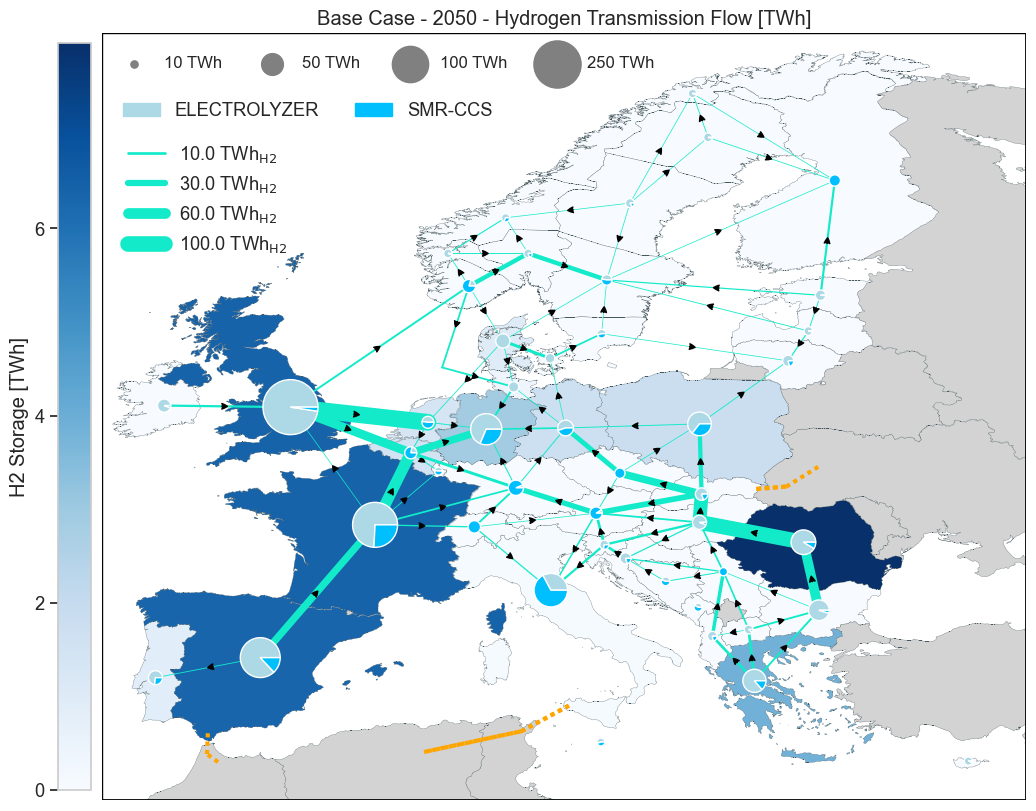

In [ ]:
### 1.1.5 Plotting map of transmission capacity
fig, ax = res_1.plot_map(scenario='Base Case', year=2050, commodity='Hydrogen', lines='FlowYear', generation='Production', background='H2 Storage')

Found MainResults in ../master_thesis/main_results/MainResults/MainResults_B_B.gdx


/Users/maxfavrot/Balmorel/pybalmorel_MaxF/src/pybalmorel/plotting/maps_balmorel.py:747: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_line_new = pd.concat([df_line_new, df_line.loc[[k]]], ignore_index=True)


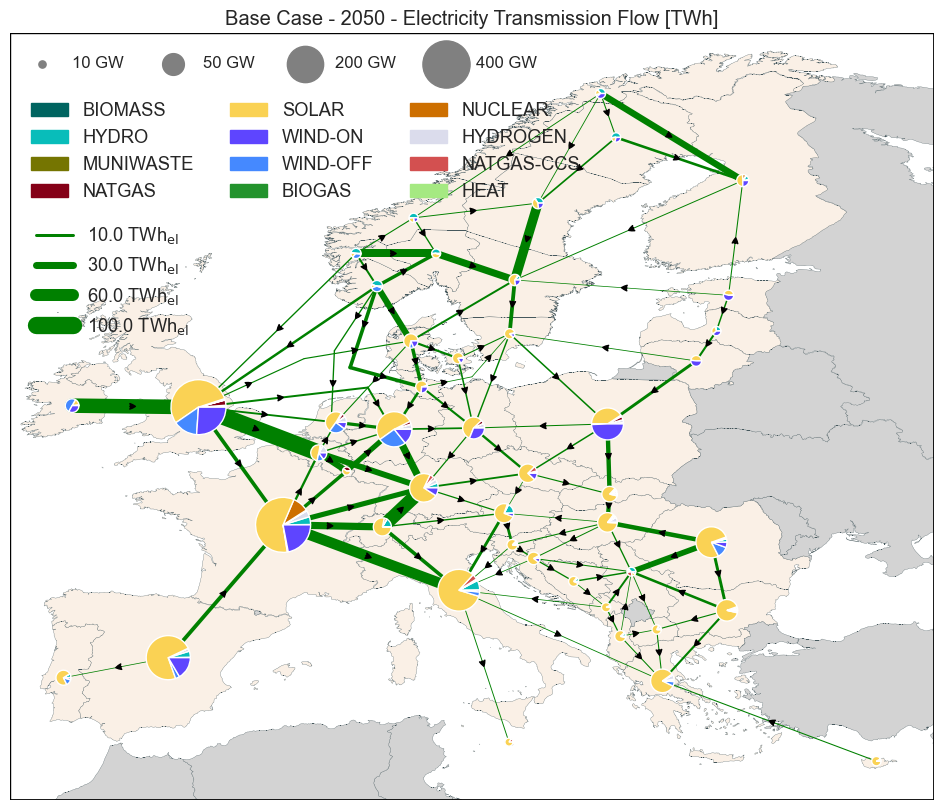

In [ ]:
### 1.1.5 Plotting map of transmission capacity
fig, ax = res_1.plot_map(scenario='Base Case', year=2050, commodity='Electricity', lines='FlowYear', generation='Capacity', generation_var='FFF', legend_show=True)

In [27]:
### 1.1.3 Plotting bar charts with an interactive gui
res.interactive_bar_chart()

Result type: balmorel


GridBox(children=(Dropdown(description='Table:', layout=Layout(width='80%'), options=('F_CONS_YCRA', 'F_CONS_Y…

Output()

Stack(children=(GridBox(children=(SelectMultiple(description='Scenario', index=(0,), layout=Layout(height='99%…

Output()

Output()

HBox()

Output()

Output()

Output()